In [1]:
# Importing Libraries
import ast # For string conversion into list object
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # To add percentage sign to y axis ticks

plt.close('all') # close all open plots

import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# in column job_skills, make list from string into panda series (list) object using ast.literal_eval
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

In [ ]:
# In plots, FuncFormatter is to format x/y axis ticks as £K
from matplotlib.ticker import FuncFormatter
def pounds_k(x, pos):
    return f"£{x/1000:.0f}K"

# In scatterplots, adjustText prevents overlap of point labels
from adjustText import adjust_text

In [ ]:
df_UK = df[df["job_country"] == "United Kingdom"].copy()

df_UK = df_UK.dropna(subset="salary_year_avg")

df_UK

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[python, numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear..."
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}"
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[vba, python, r, oracle, sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [..."
9903,Senior Data Engineer,Senior Satellite Analytics Data Engineer,"Edinburgh, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-08-10 13:34:53,False,False,United Kingdom,year,147500.0,NaN,Verisk,"[python, sql, nosql, mongodb, mongodb, elastic...","{'cloud': ['aws'], 'databases': ['mongodb', 'e..."
13764,Data Scientist,Programmatic Data Specialist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 13:22:50,False,False,United Kingdom,year,109500.0,NaN,Publicis Groupe,"[excel, powerpoint, flow]","{'analyst_tools': ['excel', 'powerpoint'], 'ot..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781461,Data Scientist,Data Scientist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-04-04 06:31:10,False,False,United Kingdom,year,88128.0,NaN,Kuda Technologies Ltd,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
783284,Senior Data Scientist,Senior Data Scientist,"Belfast, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-28 06:14:36,False,False,United Kingdom,year,157500.0,NaN,Axiom,"[sql, r, python, aws, redshift, spark, gitlab,...","{'async': ['jira', 'confluence'], 'cloud': ['a..."
783436,Data Scientist,Insight Analyst,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 06:36:08,True,False,United Kingdom,year,72900.0,NaN,Xiatech,"[html, python, css, javascript, sql, bigquery,...","{'analyst_tools': ['tableau'], 'async': ['jira..."
783598,Data Engineer,Data Engineer,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-05-02 06:18:42,False,False,United Kingdom,year,96773.0,NaN,Prevail,"[python, java, scala, c#, r, redshift, aws]","{'cloud': ['redshift', 'aws'], 'programming': ..."


# Analyse and Plot Scatter plot

In [ ]:
df_UK_exploded = df_UK.explode("job_skills")

df_UK_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,python,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,numpy,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,pandas,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,scikit-learn,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,excel,"{'analyst_tools': ['excel', 'word', 'outlook']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,aws,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o..."
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,pandas,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o..."
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,flow,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o..."
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,git,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o..."


In [6]:
# Pivot data by job skills to see how many jobs each skill contains and what is the median salary
df_UK_top_skills = (df_UK_exploded
                    .groupby("job_skills")["salary_year_avg"]
                    .agg(["count", "median"])
                    .sort_values(by="count", ascending=False)
                )

df_UK_top_skills

,count,median
job_skills,,
python,169,111175.0
sql,160,105300.0
aws,92,131723.5
excel,50,89100.0
tableau,47,111175.0
...,...,...
sharepoint,1,100500.0
terminal,1,53014.0
trello,1,89100.0


In [ ]:
# Add percentage column which consists of 
# adding a column of total_jobs from original dataframe which is len of dataframe
# and then dividing the count of jobs by it and then multiplying by 100
df_UK_top_skills["total_jobs"] = len(df_UK)

df_UK_top_skills["percentage"] = (df_UK_top_skills["count"] / df_UK_top_skills["total_jobs"]) * 100

df_UK_top_skills

,count,median,total_jobs,percentage
job_skills,,,,
python,169,111175.0,287,58.885017
sql,160,105300.0,287,55.749129
aws,92,131723.5,287,32.055749
excel,50,89100.0,287,17.421603
tableau,47,111175.0,287,16.376307
...,...,...,...,...
sharepoint,1,100500.0,287,0.348432
terminal,1,53014.0,287,0.348432
trello,1,89100.0,287,0.348432


## Plot on scatterplot

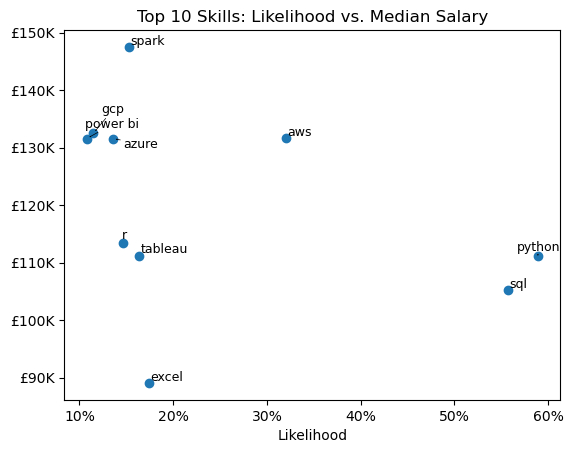

In [37]:
# Make subset of data returning top 10 skills
df_top_10 = df_UK_top_skills.head(10)

# Plot scatterplot
plt.scatter(df_top_10["percentage"], df_top_10["median"])

# Format X and Y axis ticks
ax = plt.gca() # Get current axes

# Format Y-axis to £K
ax.yaxis.set_major_formatter(mtick.FuncFormatter(pounds_k))

# Format X-axis to %
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# Add data labels from the df_UK_top_skills dataframe
texts = [] # initialise empty list
for skill, row in df_top_10.iterrows():
    # Append each text object to the list
    texts.append(
        plt.text(
            x=row["percentage"], 
            y=row["median"], 
            s=skill, 
            fontsize=9
        )
    )

# Add arrows and ensure data labels do not overlap each other
# This is using adjust_text module
adjust_text(
    texts, 
    arrowprops=dict(arrowstyle="->", color='black', lw=0.5) # Adds a pointer line if text moves too far
)

plt.title("Top 10 Skills: Likelihood vs. Median Salary")
plt.xlabel("Likelihood");